In [17]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [3]:
df = pd.read_csv("C:/Users/qtg4ys/Documents/DS3001/DS4002/weather_crime_final.csv")
print(df.columns.tolist())

#Sort Data into correct time order
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['city','date'])

#Handle any potential missing weather values
df['Daily Temperature Mean'] = df.groupby('city')['Daily Temperature Mean'].transform(lambda x: x.interpolate())
df['Daily Precipitation Sum'] = df.groupby('city')['Daily Precipitation Sum'].transform(lambda x: x.fillna(0))

['city', 'date', 'total_crime_count', 'violent_count', 'property_count', 'other_count', 'Daily Temperature Mean', 'Daily Precipitation Sum']


In [4]:
#Create Lags
lags = [1,7,14]

for lag in lags:
    df[f'crime_lag_{lag}'] = df.groupby('city')['total_crime_count'].shift(lag)
df = df.dropna()

In [5]:
#Train test split
train_list = []
test_list = []

for city in df['city'].unique():
    
    city_df = df[df['city']==city]
    
    split = int(len(city_df)*0.8)
    
    train_list.append(city_df.iloc[:split])
    test_list.append(city_df.iloc[split:])

train = pd.concat(train_list)
test = pd.concat(test_list)

In [6]:
#Linear regression crime only
baseline_features = [
    'crime_lag_1',
    'crime_lag_7',
    'crime_lag_14'
]

X_train = train[baseline_features]
y_train = train['total_crime_count']

X_test = test[baseline_features]
y_test = test['total_crime_count']

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

In [7]:
#Linear regression weather and crime
weather_features = [
    'crime_lag_1',
    'crime_lag_7',
    'crime_lag_14',
    'Daily Temperature Mean',
    'Daily Precipitation Sum'
]

X_train_w = train[weather_features]
X_test_w = test[weather_features]

weather_model = LinearRegression()
weather_model.fit(X_train_w, y_train)

weather_preds = weather_model.predict(X_test_w)

In [8]:
def evaluate(y_true, preds):

    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    return mae, rmse, r2


baseline_results = evaluate(y_test, baseline_preds)
weather_results = evaluate(y_test, weather_preds)

print("Baseline (Crime Only)")
print("MAE:", baseline_results[0])
print("RMSE:", baseline_results[1])
print("R2:", baseline_results[2])

print()

print("Weather Model")
print("MAE:", weather_results[0])
print("RMSE:", weather_results[1])
print("R2:", weather_results[2])

Baseline (Crime Only)
MAE: 31.834316965880298
RMSE: 56.21039516425105
R2: 0.992026655449657

Weather Model
MAE: 32.46724508560743
RMSE: 55.28331625102231
R2: 0.9922874955329617


In [9]:
rmse_improvement = (baseline_results[1] - weather_results[1]) / baseline_results[1] * 100

print("RMSE Improvement (%):", rmse_improvement)

RMSE Improvement (%): 1.6493015402573463


In [10]:
#Arimax

# set index
train = train.set_index('date')
test = test.set_index('date')

train_exog = train[['Daily Temperature Mean','Daily Precipitation Sum']]
test_exog = test[['Daily Temperature Mean','Daily Precipitation Sum']]

model = SARIMAX(
    train['total_crime_count'],
    exog=train_exog,
    order=(1,0,1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

arimax_preds = results.forecast(
    steps=len(test),
    exog=test_exog
)

rmse_arimax = np.sqrt(mean_squared_error(test['total_crime_count'], arimax_preds))

print("ARIMAX RMSE:", rmse_arimax)

C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates

ARIMAX RMSE: 1046.4430272810596


C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\qtg4ys\Documents\DS3001\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [11]:
df['total_crime_count'].describe()

count    5788.000000
mean      575.288010
std       610.081383
min         2.000000
25%        33.500000
50%       277.500000
75%       932.750000
max      1908.000000
Name: total_crime_count, dtype: float64

In [12]:
rmse = 3366
mean_crime = df['total_crime_count'].mean()

nrmse = rmse / mean_crime
print(nrmse)

5.850982366033419


In [13]:
test = test.copy()

test['baseline_pred'] = baseline_preds
test['weather_pred'] = weather_preds

city_results = []

for city in test['city'].unique():

    city_test = test[test['city'] == city]

    rmse_base = np.sqrt(mean_squared_error(
        city_test['total_crime_count'],
        city_test['baseline_pred']
    ))

    rmse_weather = np.sqrt(mean_squared_error(
        city_test['total_crime_count'],
        city_test['weather_pred']
    ))

    improvement = (rmse_base - rmse_weather) / rmse_base * 100

    city_results.append({
        "city": city,
        "baseline_rmse": rmse_base,
        "weather_rmse": rmse_weather,
        "improvement_percent": improvement
    })

city_results = pd.DataFrame(city_results)

print(city_results)

              city  baseline_rmse  weather_rmse  improvement_percent
0  Charlottesville       4.967132      9.887389           -99.056307
1          Chicago      52.030090     50.507365             2.926624
2           Durham      13.651872     15.754734           -15.403468
3              NYC      98.591368     96.581645             2.038437


In [16]:
train = train.reset_index()
test = test.reset_index()

arimax_results = []
large_cities = ['Chicago', 'NYC']

for city in df['city'].unique():
    city_train = train[train['city'] == city].copy()
    city_test = test[test['city'] == city].copy()
    
    city_train = city_train.set_index('date')
    city_test = city_test.set_index('date')
    
    city_train.index.freq = 'D'
    city_test.index.freq = 'D'
    
    exog_cols = ['Daily Temperature Mean', 'Daily Precipitation Sum']
    order = (2, 1, 2) if city in large_cities else (1, 0, 1)
    
    model = SARIMAX(
        city_train['total_crime_count'],
        exog=city_train[exog_cols],
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    res = model.fit(disp=False, maxiter=200)
    
    forecast = res.get_forecast(steps=len(city_test), exog=city_test[exog_cols])
    preds = forecast.predicted_mean
    ci = forecast.summary_frame()
    
    rmse = np.sqrt(mean_squared_error(city_test['total_crime_count'], preds))
    
    arimax_results.append({
        'city': city,
        'arimax_rmse': rmse,
        'model': res,
        'preds': preds,
        'actuals': city_test['total_crime_count'],
        'ci': ci
    })
    
    print(f"{city} — ARIMAX RMSE: {rmse:.4f}")

arimax_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('model', 'preds', 'actuals', 'ci')} 
                           for r in arimax_results])
print(arimax_df)

Charlottesville — ARIMAX RMSE: 4.5232
Chicago — ARIMAX RMSE: 51.3115
Durham — ARIMAX RMSE: 14.8753
NYC — ARIMAX RMSE: 146.4490
              city  arimax_rmse
0  Charlottesville     4.523184
1          Chicago    51.311457
2           Durham    14.875318
3              NYC   146.449049


              city  nrmse_baseline  nrmse_weather  nrmse_arimax
0  Charlottesville        0.336087       0.669002      0.306048
1          Chicago        0.078830       0.076523      0.077741
2           Durham        0.191647       0.221167      0.208822
3              NYC        0.062964       0.061680      0.093527


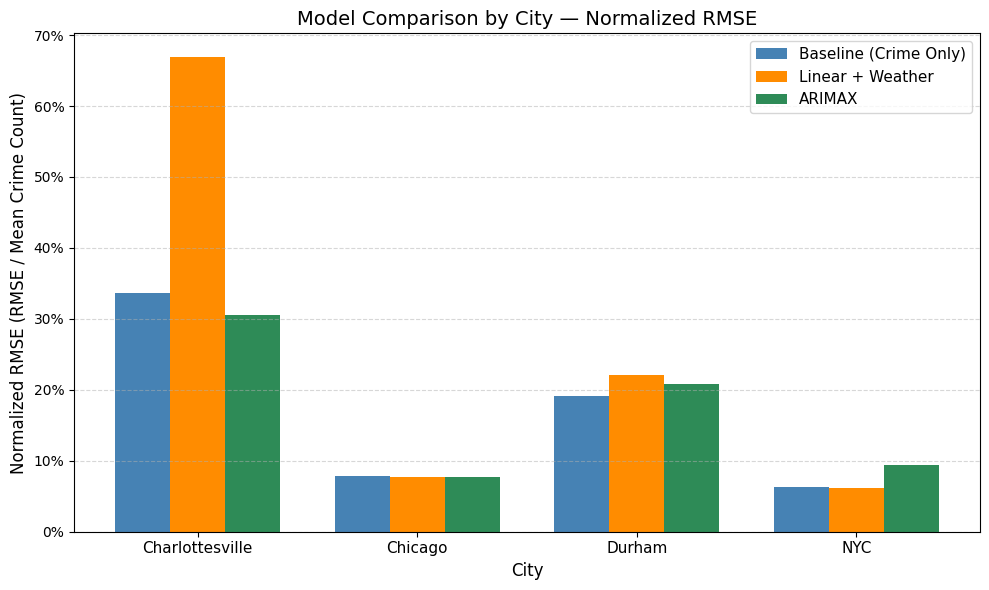

In [18]:
# Build unified results table
city_results_full = city_results.merge(arimax_df, on='city')

# Add mean actuals for NRMSE normalization
mean_actuals = (
    test.groupby('city')['total_crime_count'].mean().reset_index()
    .rename(columns={'total_crime_count': 'mean_actuals'})
)
city_results_full = city_results_full.merge(mean_actuals, on='city')

# Compute NRMSE for all three models
city_results_full['nrmse_baseline'] = city_results_full['baseline_rmse'] / city_results_full['mean_actuals']
city_results_full['nrmse_weather']  = city_results_full['weather_rmse']  / city_results_full['mean_actuals']
city_results_full['nrmse_arimax']   = city_results_full['arimax_rmse']   / city_results_full['mean_actuals']

print(city_results_full[['city','nrmse_baseline','nrmse_weather','nrmse_arimax']])

# Plot
cities = city_results_full['city']
x = np.arange(len(cities))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, city_results_full['nrmse_baseline'], width, label='Baseline (Crime Only)', color='steelblue')
bars2 = ax.bar(x,         city_results_full['nrmse_weather'],  width, label='Linear + Weather',      color='darkorange')
bars3 = ax.bar(x + width, city_results_full['nrmse_arimax'],   width, label='ARIMAX',                color='seagreen')

ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Normalized RMSE (RMSE / Mean Crime Count)', fontsize=12)
ax.set_title('Model Comparison by City — Normalized RMSE', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(cities, fontsize=11)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('nrmse_comparison.png', dpi=150)
plt.show()

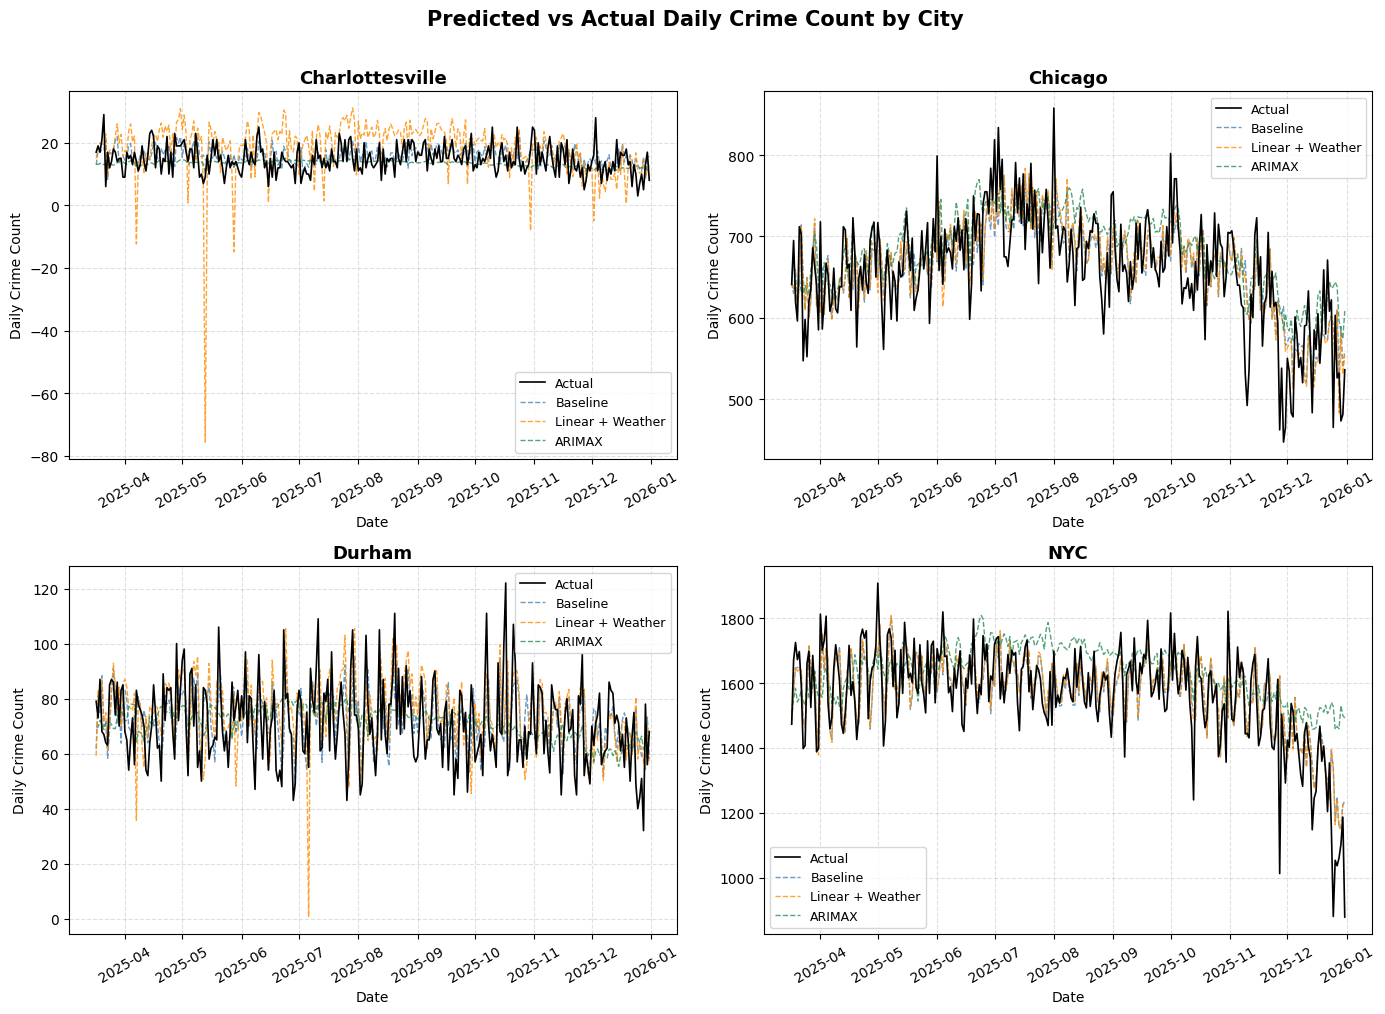

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, city in enumerate(city_results_full['city']):
    ax = axes[idx]
    
    # Get actuals and linear model preds from test
    city_test = test[test['city'] == city].copy()
    city_test = city_test.sort_values('date')
    
    # Get ARIMAX preds from arimax_results
    arimax_entry = next(r for r in arimax_results if r['city'] == city)
    arimax_preds = arimax_entry['preds']
    
    ax.plot(city_test['date'], city_test['total_crime_count'],
            color='black', linewidth=1.2, label='Actual', zorder=3)
    ax.plot(city_test['date'], city_test['baseline_pred'],
            color='steelblue', linewidth=1, linestyle='--', label='Baseline', alpha=0.8)
    ax.plot(city_test['date'], city_test['weather_pred'],
            color='darkorange', linewidth=1, linestyle='--', label='Linear + Weather', alpha=0.8)
    ax.plot(arimax_preds.index, arimax_preds.values,
            color='seagreen', linewidth=1, linestyle='--', label='ARIMAX', alpha=0.8)
    
    ax.set_title(city, fontsize=13, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Daily Crime Count', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(linestyle='--', alpha=0.4)
    ax.legend(fontsize=9)

fig.suptitle('Predicted vs Actual Daily Crime Count by City', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()